# Open API를 활용한 금융데이터 수집과 Python 분석

- API 요청 → JSON 응답 → DataFrame 변환 → 기초분석 → 시각화
- 실습에는 별도 인증키가 필요 없는 Frankfurter 환율 API를 사용

## 1단계. 라이브러리 불러오기

- requests: API 서버에 데이터 요청
- pandas: JSON을 표 형태로 변환
- matplotlib: 환율 추세 시각화

In [1]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

# Windows 한글 폰트
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

## 2단계. API 요청 조건 설정

- URL 어느 서버에 요청하는가?
- Parameter 어떤 데이터를 요청하는가?
- 파라미터	의미
- from:	   조회 시작일
- to:	   조회 종료일
- base:	   기준통화
- quotes:   비교통화

- 조회기간 : 2026.1.1-2026.7.31
- 환율: 원/달러

In [2]:
url = "https://api.frankfurter.dev/v2/rates"

params = {
    "from": "2026-01-01",
    "to": "2026-07-31",
    "base": "USD",
    "quotes": "KRW"
}

## 3단계. API 호출

In [3]:
response = requests.get(
    url,
    params=params,
    timeout=10
)

print("요청 주소:")
print(response.url)

print("\n상태코드:")
print(response.status_code)

요청 주소:
https://api.frankfurter.dev/v2/rates?from=2026-01-01&to=2026-07-31&base=USD&quotes=KRW

상태코드:
200


In [ ]:
# 상태코드 200은 서버가 요청을 정상적으로 처리했다는 의미입니다.

## 4단계. 오류 확인

In [4]:
if response.status_code == 200:
    print("API 요청 성공")
else:
    print("API 요청 실패")
    print(response.text)

API 요청 성공


## 5단계. JSON 응답 확인

In [7]:
data = response.json()

print(type(data))
print(data[:3])

<class 'list'>
[{'date': '2026-01-01', 'base': 'USD', 'quote': 'KRW', 'rate': 1442.41}, {'date': '2026-01-02', 'base': 'USD', 'quote': 'KRW', 'rate': 1443.07}, {'date': '2026-01-03', 'base': 'USD', 'quote': 'KRW', 'rate': 1443.24}]


In [ ]:
# { }: 하나의 환율 데이터
# [ ]: 여러 날짜의 환율 목록
# date: 기준일
# rate: 환율값

## 6단계. JSON을 DataFrame으로 변환

- JSON은 API에서 데이터를 전달받는 형식이고, DataFrame은 Python에서 분석하기 좋은 표 형식입니다.

In [8]:
df = pd.DataFrame(data)

display(df.head())

,date,base,quote,rate
0,2026-01-01,USD,KRW,1442.41
1,2026-01-02,USD,KRW,1443.07
2,2026-01-03,USD,KRW,1443.24
3,2026-01-04,USD,KRW,1443.27
4,2026-01-05,USD,KRW,1446.59


## 7단계. 데이터 구조 확인

In [9]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   date    212 non-null    object 
 1   base    212 non-null    object 
 2   quote   212 non-null    object 
 3   rate    212 non-null    float64
dtypes: float64(1), object(3)
memory usage: 6.8+ KB
None


In [11]:
print(df.describe())

              rate
count   212.000000
mean   1485.183066
std      30.424294
min    1428.680000
25%    1463.805000
50%    1479.670000
75%    1508.067500
max    1552.830000


In [ ]:
# 확인
# 데이터 개수
# 날짜 열의 자료형
# 환율의 평균
# 최솟값
# 최댓값
# 표준편차

## 8단계. 날짜 데이터 전처리

- API에서 받은 날짜가 문자열일 수 있으므로 날짜형으로 변환하고, 환율도 숫자형으로 변환합니다.

In [12]:
df["date"] = pd.to_datetime(
    df["date"]
)

df["rate"] = pd.to_numeric(
    df["rate"],
    errors="coerce"
)

df = df.dropna(
    subset=["date", "rate"]
)

df = df.sort_values(
    "date"
)

display(df.head())

,date,base,quote,rate
0,2026-01-01,USD,KRW,1442.41
1,2026-01-02,USD,KRW,1443.07
2,2026-01-03,USD,KRW,1443.24
3,2026-01-04,USD,KRW,1443.27
4,2026-01-05,USD,KRW,1446.59


## 9단계. 환율 기초통계 확인

In [13]:
print(
    f"평균 환율: {df['rate'].mean():,.2f}원"
)

print(
    f"최저 환율: {df['rate'].min():,.2f}원"
)

print(
    f"최고 환율: {df['rate'].max():,.2f}원"
)

print(
    f"환율 표준편차: {df['rate'].std():,.2f}원"
)

평균 환율: 1,485.18원
최저 환율: 1,428.68원
최고 환율: 1,552.83원
환율 표준편차: 30.42원


## 10단계. 환율 추세 그래프

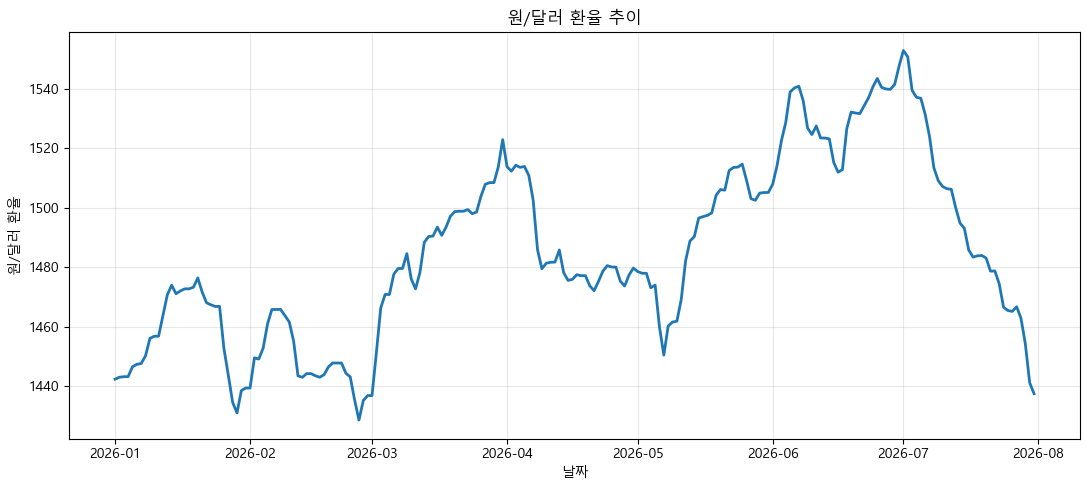

In [14]:
plt.figure(figsize=(11, 5))

plt.plot(
    df["date"],
    df["rate"],
    linewidth=2
)

plt.title("원/달러 환율 추이")
plt.xlabel("날짜")
plt.ylabel("원/달러 환율")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

- 환율은 전체적으로 상승했는가, 하락했는가?
- 환율이 크게 변한 구간은 어디인가?
- 변동성이 확대된 시점은 언제인가?

## 최종 마무리

- Open API는 데이터를 가져오는 통로이다.
- requests는 데이터를 요청하고,
- JSON은 데이터를 전달하며,
- Pandas는 데이터를 분석 가능한 표로 바꾸고,
- Matplotlib은 데이터의 흐름을 보여준다.